In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
file_path = '../dataset/2_Mall_Customers_Adj.csv'
df = pd.read_csv(file_path)
columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']
df.columns = columns
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,1,19,15,54.12
1,2,1,21,15,47.86
2,3,0,20,16,50.50
3,4,0,23,16,52.39
4,5,0,31,17,38.41


Correlation Matrix:
               CustomerID    Gender       Age  AnnualIncome  SpendingScore
CustomerID       1.000000  0.057400 -0.026763      0.977548       0.746587
Gender           0.057400  1.000000  0.060867      0.056410       0.016076
Age             -0.026763  0.060867  1.000000     -0.012398      -0.560406
AnnualIncome     0.977548  0.056410 -0.012398      1.000000       0.756499
SpendingScore    0.746587  0.016076 -0.560406      0.756499       1.000000


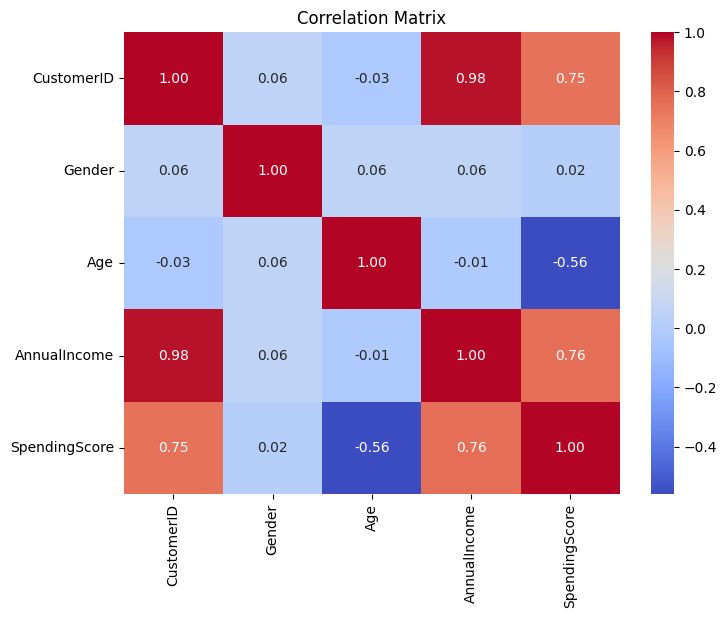

In [3]:
corr_matrix = df.corr()
print('Correlation Matrix:')
print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
# Features และ Target
X = df[['Gender', 'Age', 'AnnualIncome']]
y = df['SpendingScore']

# แบ่งข้อมูล train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ทดสอบ Polynomial Regression หลาย degree
degrees = [1, 2, 3, 4, 5]
mse_list = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    print(f'Degree {degree}: MSE = {mse:.2f}')
    if degree == 2:  # แสดงรายละเอียดของ degree ที่เหมาะสม
        print(f'\nPolynomial Degree 2 Coefficients:')
        print(model.coef_)
        print(f'Intercept: {model.intercept_}')
        print('\nตัวอย่างค่าทำนาย (y_pred) เทียบกับจริง (y_test):')
        compare_df = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
        print(compare_df.head(10))

Degree 1: MSE = 22.62
Degree 2: MSE = 22.38

Polynomial Degree 2 Coefficients:
[ 0.00000000e+00  6.97376576e-01 -5.82471544e-01  4.76590413e-01
  6.97376576e-01 -9.95768457e-02  5.27770431e-02  9.63032092e-04
 -5.41339362e-04 -6.18554854e-04]
Intercept: 56.2207005227708

ตัวอย่างค่าทำนาย (y_pred) เทียบกับจริง (y_test):
   y_true     y_pred
0   69.37  70.556720
1   44.95  53.178234
2   37.57  34.509379
3   74.69  71.630815
4   53.23  52.926197
5   78.63  73.197824
6   57.82  59.187448
7   65.23  71.363635
8   68.91  63.208918
9   55.64  59.935600
Degree 3: MSE = 27.13
Degree 4: MSE = 29.44
Degree 5: MSE = 30.37


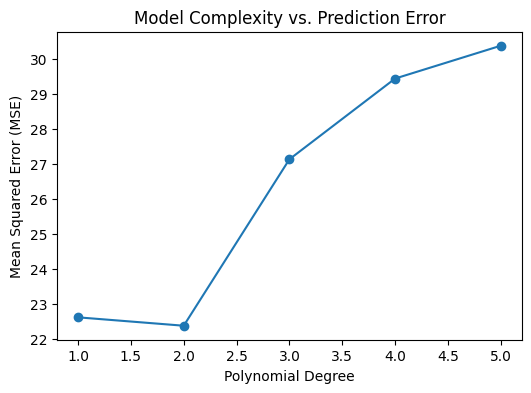

In [8]:
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Model Complexity vs. Prediction Error')
plt.show()

In [11]:
best_degree = degrees[np.argmin(mse_list)]
print(f'Polynomial Degree = {best_degree}')


Polynomial Degree = 2


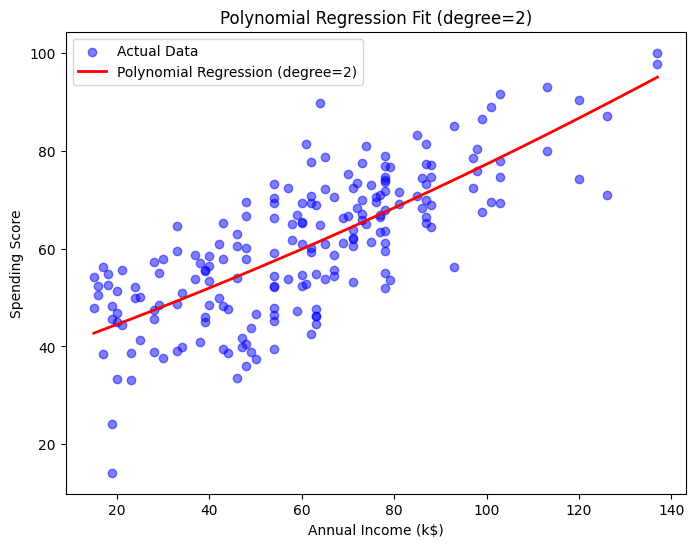

In [13]:
# --- Polynomial Regression Visualization ---
from sklearn.pipeline import make_pipeline

# เลือก degree ที่เหมาะสมที่สุด (สมมติว่าคุณมีตัวแปร mse_list และ degrees จาก cell ก่อนหน้า)
best_degree = degrees[np.argmin(mse_list)]

# Fit polynomial regression กับข้อมูลทั้งหมด (AnnualIncome -> SpendingScore)
X_plot = df[['AnnualIncome']].values
X_plot_range = np.linspace(X_plot.min(), X_plot.max(), 200).reshape(-1, 1)
poly_model = make_pipeline(PolynomialFeatures(degree=best_degree), LinearRegression())
poly_model.fit(X_plot, y)
y_plot = poly_model.predict(X_plot_range)

plt.figure(figsize=(8,6))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], color='blue', label='Actual Data', alpha=0.5)
plt.plot(X_plot_range, y_plot, color='red', linewidth=2, label=f'Polynomial Regression (degree={best_degree})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title(f'Polynomial Regression Fit (degree={best_degree})')
plt.legend()
plt.show()

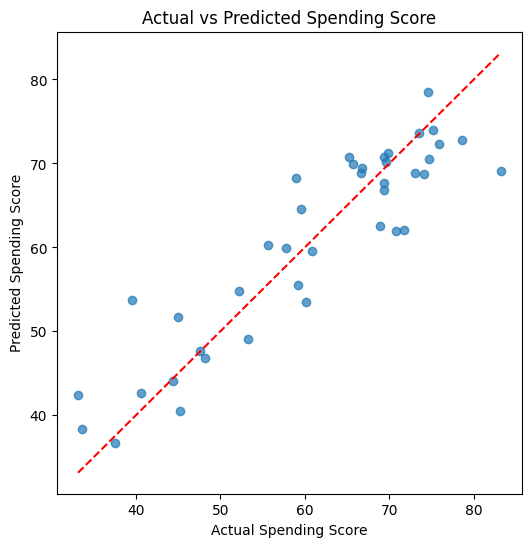

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Spending Score')
plt.ylabel('Predicted Spending Score')
plt.title('Actual vs Predicted Spending Score')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

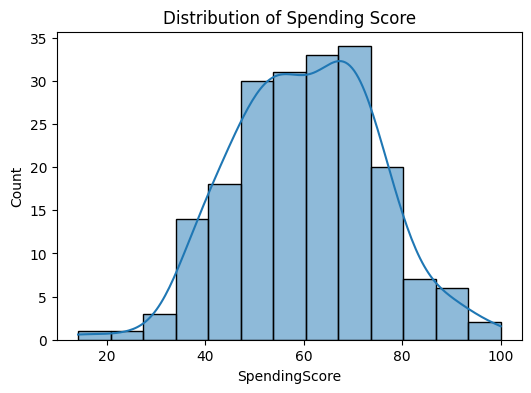

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['SpendingScore'], kde=True)
plt.title('Distribution of Spending Score')
plt.show()

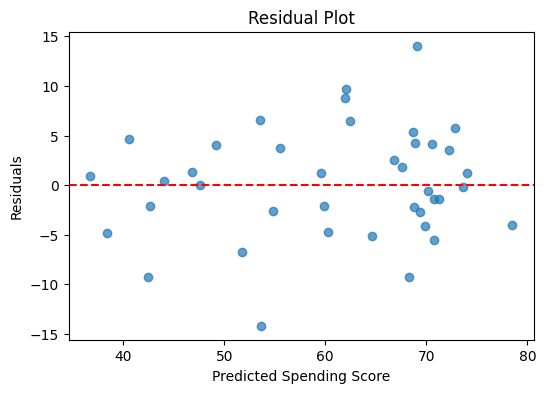

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Spending Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

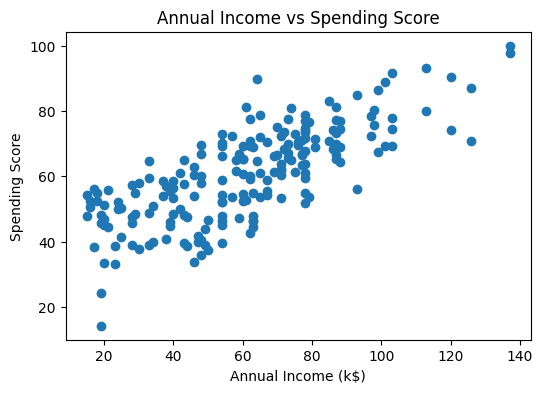

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df['AnnualIncome'], df['SpendingScore'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Annual Income vs Spending Score')
plt.show()